## Import

In [1]:
import pandas as pd
pd.set_option("display.max_columns", 100)

import numpy as np

import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 14

import seaborn as sns

from pathlib import Path
import joblib

from titanic.data import load_processed_data
from titanic.selection import select_model_features
from titanic.preprocessing import (
    preprocess_train_test,
    DEFAULT_CATEGORICAL_FEATURES,
    DEFAULT_BINARY_FEATURES,
    DEFAULT_NUMERIC_FEATURES,
)
from titanic.models import get_baseline_models
from titanic.validation import benchmark_models
from titanic.predict import make_predictions
from titanic.evaluate import evaluate_submission
from titanic.tuning import tune_model
from titanic.hyperparameters import MODEL_GRIDS

## Data loading

In [2]:
df = load_processed_data()

print(df.shape)
df.head()

(1309, 45)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,Title,HasNickname,SexIsMale,IsAlone,HasFamily,FamilySize,TicketText,TicketNumber,TicketNumberClass,HasCabin,Deck,CabinNumber,CabinCount,SurnameValueCounts,FamilySizeValueCounts,CabinValueCounts,TicketValueCounts,FareValueCounts,FarePerTicketPassenger,FarePerTicketPassenger_log1p,GroupSize,GroupType,FarePerPerson,FarePerPerson_log1p,AgeETR,AgeGroup,AgeDecade,IsChild,FamilySurvivalRate,FamilySurvivalRateCount,TicketSurvivalRate,TicketSurvivalRateCount
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr,0,1,0,1,2,A5,21171,2,0,NaN,NaN,0,2,235,NaN,1,18,7.25000,2.110213,2,couple,3.625000,1.531476,22.0,young_adult,20-29,0,0.319865,2.0,0.383838,1.0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs,1,0,0,1,2,PC,17599,1,1,C,85.0,1,2,235,2.0,2,2,35.64165,3.601186,2,couple,35.641650,3.601186,38.0,adult,30-39,0,0.383838,1.0,0.383838,1.0
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss,0,0,1,0,1,STONO2,3101282,3,0,NaN,NaN,0,1,790,NaN,1,23,7.92500,2.188856,3,family,2.641667,1.292441,26.0,adult,20-29,0,0.383838,1.0,0.383838,1.0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs,1,0,0,1,2,NaN,113803,1,1,C,123.0,1,2,235,2.0,2,6,26.55000,3.316003,2,couple,26.550000,3.316003,35.0,adult,30-39,0,0.319865,2.0,0.319865,2.0
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr,0,1,1,0,1,NaN,373450,3,0,NaN,NaN,0,2,790,NaN,1,61,8.05000,2.202765,1,single,8.050000,2.202765,35.0,adult,30-39,0,0.486532,2.0,0.383838,1.0


## Selection des features finales

In [3]:
df_model = select_model_features(
    df,
    include_target=True
)

features = [
    col for col in df_model.columns
    if col != "Survived"
]

features

['Pclass',
 'Title',
 'HasNickname',
 'AgeETR',
 'IsChild',
 'IsAlone',
 'FamilySurvivalRate',
 'FarePerPerson_log1p',
 'TicketSurvivalRate',
 'HasCabin']

## Preprocessing

In [4]:
X_train, y_train, X_test, preprocessor = preprocess_train_test(
    df_model,
    features=features,
    target="Survived",
    scale_numeric=True,
    categorical_features=DEFAULT_CATEGORICAL_FEATURES,
    binary_features=DEFAULT_BINARY_FEATURES,
    numeric_features=DEFAULT_NUMERIC_FEATURES,
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)

X_train: (891, 15)
y_train: (891,)
X_test: (418, 15)


## Benchmark CV des modèles

In [5]:
models = get_baseline_models(random_state=42)

cv_results = benchmark_models(
    models=models,
    X=X_train,
    y=y_train,
    scoring="accuracy",
    n_splits=10,
    random_state=42,
)

cv_results

,model,train_score_mean,train_score_std,test_score_mean,test_score_std
0,SVC,0.864446,0.003390,0.850687,0.026313
1,GradientBoostingClassifier,0.907344,0.006986,0.845056,0.028990
2,AdaBoostClassifier,0.846987,0.004784,0.843958,0.021794
3,LogisticRegression,0.845990,0.004172,0.839488,0.028535
4,XGBClassifier,0.980920,0.002682,0.830512,0.025440
5,KNeighborsClassifier,0.874173,0.002890,0.828240,0.028645
6,RandomForestClassifier,0.991645,0.000974,0.827116,0.031244
7,BaggingClassifier,0.976681,0.003863,0.827116,0.033203
8,ExtraTreesClassifier,0.991645,0.000974,0.809151,0.036784
9,DecisionTreeClassifier,0.991645,0.000974,0.787815,0.050053


## Fonction pour évaluer localement un modèle

In [6]:
def evaluate_model_locally(model, model_name, X_train, y_train, X_test, df_model):
    model.fit(X_train, y_train)

    test_df = df_model[df_model["Survived"].isna()].copy()

    predictions_df = make_predictions(
        model=model,
        X_test=X_test,
        passenger_ids=test_df.index,
    )

    score = evaluate_submission(
        predictions_df,
        responses_path="../data/responses/responses.csv",
        verbose=False,
    )

    return {
        "model": model_name,
        "local_score": score,
        "predictions": predictions_df,
    }

## Évaluation locale de tous les modèles

In [7]:
local_results = []

for model_name, model in models.items():
    result = evaluate_model_locally(
        model=model,
        model_name=model_name,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        df_model=df_model,
    )

    local_results.append({
        "model": result["model"],
        "local_score": result["local_score"],
    })

local_results_df = (
    pd.DataFrame(local_results)
    .sort_values("local_score", ascending=False)
    .reset_index(drop=True)
)

local_results_df

,model,local_score
0,SVC,0.801435
1,KNeighborsClassifier,0.789474
2,GradientBoostingClassifier,0.784689
3,LogisticRegression,0.779904
4,BaggingClassifier,0.779904
5,RandomForestClassifier,0.772727
6,AdaBoostClassifier,0.772727
7,ExtraTreesClassifier,0.767943
8,XGBClassifier,0.751196
9,GaussianNB,0.746411


## Comparaison CV vs score local

In [8]:
comparison_df = (
    cv_results[["model", "test_score_mean", "test_score_std"]]
    .merge(local_results_df, on="model", how="left")
    .sort_values("local_score", ascending=False)
    .reset_index(drop=True)
)

comparison_df

,model,test_score_mean,test_score_std,local_score
0,SVC,0.850687,0.026313,0.801435
1,KNeighborsClassifier,0.828240,0.028645,0.789474
2,GradientBoostingClassifier,0.845056,0.028990,0.784689
3,BaggingClassifier,0.827116,0.033203,0.779904
4,LogisticRegression,0.839488,0.028535,0.779904
5,AdaBoostClassifier,0.843958,0.021794,0.772727
6,RandomForestClassifier,0.827116,0.031244,0.772727
7,ExtraTreesClassifier,0.809151,0.036784,0.767943
8,XGBClassifier,0.830512,0.025440,0.751196
9,GaussianNB,0.784494,0.021936,0.746411


## Visualisation CV vs Local

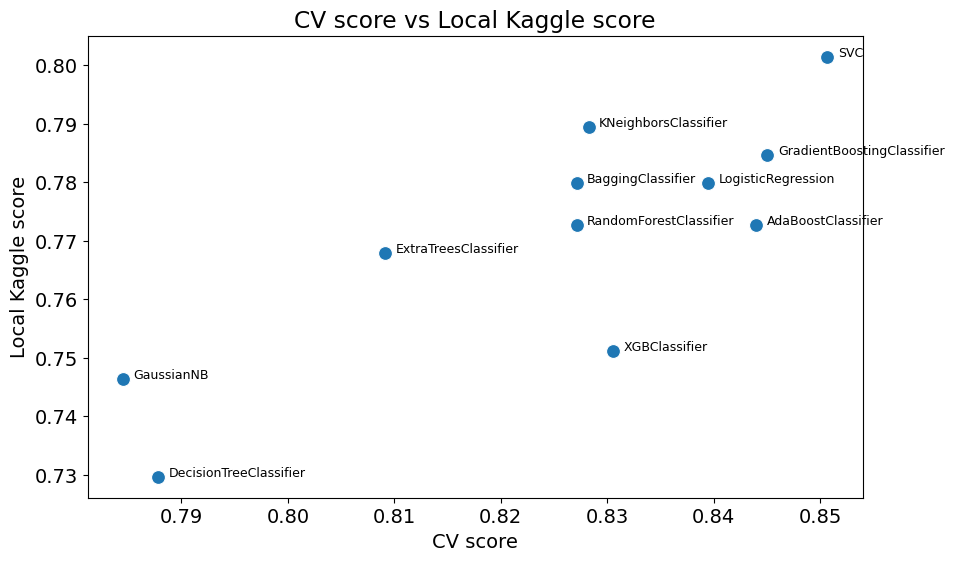

In [9]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=comparison_df,
    x="test_score_mean",
    y="local_score",
    s=100,
)

for _, row in comparison_df.iterrows():
    plt.text(
        row["test_score_mean"] + 0.001,
        row["local_score"],
        row["model"],
        fontsize=9,
    )

plt.xlabel("CV score")
plt.ylabel("Local Kaggle score")
plt.title("CV score vs Local Kaggle score")
plt.show()

## Top modèles

In [10]:
top_models = (
    comparison_df
    .sort_values("local_score", ascending=False)
    .head(5)
)

top_models

,model,test_score_mean,test_score_std,local_score
0,SVC,0.850687,0.026313,0.801435
1,KNeighborsClassifier,0.828240,0.028645,0.789474
2,GradientBoostingClassifier,0.845056,0.028990,0.784689
3,BaggingClassifier,0.827116,0.033203,0.779904
4,LogisticRegression,0.839488,0.028535,0.779904


## Choisir les modèles à tuner

In [11]:
models_to_tune = [
    model
    for model in top_models["model"].tolist()
    if model in MODEL_GRIDS
]

models_to_tune

['SVC',
 'KNeighborsClassifier',
 'GradientBoostingClassifier',
 'LogisticRegression']

## Tuning des meilleurs modèles

In [12]:
tuning_results = []

for model_name in models_to_tune:
    print(f"Tuning {model_name}...")

    grid = tune_model(
        model=MODEL_GRIDS[model_name]["model"],
        param_grid=MODEL_GRIDS[model_name]["params"],
        X=X_train,
        y=y_train,
        scoring="accuracy",
        n_splits=5,
        random_state=42,
        n_jobs=-1,
        verbose=0,
    )

    tuning_results.append({
        "model": model_name,
        "best_cv_score": grid.best_score_,
        "best_params": grid.best_params_,
        "best_estimator": grid.best_estimator_,
    })

tuning_results_df = (
    pd.DataFrame(tuning_results)
    .drop(columns=["best_estimator"])
    .sort_values("best_cv_score", ascending=False)
    .reset_index(drop=True)
)

tuning_results_df

Tuning SVC...
Tuning KNeighborsClassifier...
Tuning GradientBoostingClassifier...
Tuning LogisticRegression...


,model,best_cv_score,best_params
0,GradientBoostingClassifier,0.858584,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
1,SVC,0.850719,"{'C': 2, 'gamma': 'scale', 'kernel': 'rbf'}"
2,LogisticRegression,0.838384,"{'C': 10, 'solver': 'lbfgs'}"
3,KNeighborsClassifier,0.837267,"{'n_neighbors': 11, 'p': 1, 'weights': 'uniform'}"


## Évaluer localement les modèles tunés

In [13]:
tuned_local_results = []

for result in tuning_results:
    model_name = result["model"]
    tuned_model = result["best_estimator"]

    local_result = evaluate_model_locally(
        model=tuned_model,
        model_name=model_name,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        df_model=df_model,
    )

    tuned_local_results.append({
        "model": model_name,
        "best_cv_score": result["best_cv_score"],
        "local_score": local_result["local_score"],
        "best_params": result["best_params"],
        "estimator": tuned_model,
    })

tuned_local_results_df = (
    pd.DataFrame(tuned_local_results)
    .sort_values("local_score", ascending=False)
    .reset_index(drop=True)
)

tuned_local_results_df.drop(columns=["estimator"])

,model,best_cv_score,local_score,best_params
0,SVC,0.850719,0.801435,"{'C': 2, 'gamma': 'scale', 'kernel': 'rbf'}"
1,KNeighborsClassifier,0.837267,0.787081,"{'n_neighbors': 11, 'p': 1, 'weights': 'uniform'}"
2,GradientBoostingClassifier,0.858584,0.784689,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
3,LogisticRegression,0.838384,0.779904,"{'C': 10, 'solver': 'lbfgs'}"


## Comparaison baseline vs tuning

In [14]:
baseline_vs_tuned = (
    comparison_df[["model", "test_score_mean", "local_score"]]
    .rename(columns={
        "test_score_mean": "baseline_cv_score",
        "local_score": "baseline_local_score",
    })
    .merge(
        tuned_local_results_df[["model", "best_cv_score", "local_score"]],
        on="model",
        how="inner",
    )
    .rename(columns={
        "local_score": "tuned_local_score",
    })
)

baseline_vs_tuned["local_gain"] = (
    baseline_vs_tuned["tuned_local_score"]
    - baseline_vs_tuned["baseline_local_score"]
)

baseline_vs_tuned.sort_values("tuned_local_score", ascending=False)

,model,baseline_cv_score,baseline_local_score,best_cv_score,tuned_local_score,local_gain
0,SVC,0.850687,0.801435,0.850719,0.801435,0.000000
1,KNeighborsClassifier,0.828240,0.789474,0.837267,0.787081,-0.002392
2,GradientBoostingClassifier,0.845056,0.784689,0.858584,0.784689,0.000000
3,LogisticRegression,0.839488,0.779904,0.838384,0.779904,0.000000


## Sélection du meilleur modèle final

In [15]:
best_result = tuned_local_results_df.iloc[0]

best_model_name = best_result["model"]
best_model = best_result["estimator"]
best_local_score = best_result["local_score"]
best_params = best_result["best_params"]

print("Best model:", best_model_name)
print("Best local score:", best_local_score)
print("Best params:", best_params)

Best model: SVC
Best local score: 0.8014354066985646
Best params: {'C': 2, 'gamma': 'scale', 'kernel': 'rbf'}


## Sauvegarder le meilleur modèle

In [16]:
from pathlib import Path
import joblib

Path("../models/experiments").mkdir(parents=True, exist_ok=True)

joblib.dump(
    {
        "model": best_model,
        "model_name": best_model_name,
        "local_score": best_local_score,
        "best_params": best_params,
        "preprocessor": preprocessor,
        "features": features,
    },
    f"../models/experiments/{best_model_name}_model_selection.joblib"
)

['../models/experiments/SVC_model_selection.joblib']

## Générer une soumission finale depuis le notebook

In [17]:
test_df = df_model[df_model["Survived"].isna()].copy()

final_predictions = make_predictions(
    model=best_model,
    X_test=X_test,
    passenger_ids=test_df.index,
)

final_predictions.head()

,Survived
PassengerId,
892,0
893,1
894,0
895,0
896,1


## Évaluer la soumission finale

In [18]:
evaluate_submission(
    final_predictions,
    responses_path="../data/responses/responses.csv",
    verbose=True,
)

Local Kaggle Score: 0.8014
Compared rows: 418 / 418

Classification report:
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       260
           1       0.75      0.72      0.73       158

    accuracy                           0.80       418
   macro avg       0.79      0.78      0.79       418
weighted avg       0.80      0.80      0.80       418


Confusion matrix:
[[222  38]
 [ 45 113]]


0.8014354066985646

## Sauvegarder la soumission finale

In [19]:
Path("../data/submissions").mkdir(parents=True, exist_ok=True)

final_predictions.to_csv(
    "../data/submissions/submission_model_selection.csv",
    index=True,
)

print("Submission saved.")

Submission saved.


### Conclusion

- Meilleur modèle baseline :
- Meilleur score CV baseline :
- Meilleur score local baseline :
- Modèles tunés :
- Meilleur modèle final :
- Meilleur score local final :
- Paramètres retenus :

Remarque : le score local utilise les réponses du jeu de test. Il doit être interprété comme une validation finale, pas comme un signal à optimiser indéfiniment.